In [ ]:
!pip install gymnasium
!pip install "gymnasium[classic-control]"
!pip install swig
!pip install "gymnasium[box2d]"
!pip install numpy
!pip install stable-baselines3
!pip install shimmy
!pip install opencv-python

In [1]:
import stable_baselines3
import shimmy
import gymnasium as gym

print(f"SB3 wersja: {stable_baselines3.__version__}")

SB3 wersja: 2.8.0


In [56]:
import gymnasium as gym
from stable_baselines3 import A2C
import cv2
def run_model(model,time=1000):
    vec_env = model.get_env()
    obs = vec_env.reset()
    window_name = "Agent view"

    for i in range(time):
        action, _state = model.predict(obs,deterministic=True)
        obs,reward,done,info = vec_env.step(action)
        frame = vec_env.render()
        frame_bgr = cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
        cv2.imshow(window_name,frame_bgr)
        key = cv2.waitKey(1) & 0xFF
        if cv2.getWindowProperty(window_name,cv2.WND_PROP_VISIBLE) < 1:
            break
        if key == ord('q'):
            break
        if done:
            obs = vec_env.reset()
    cv2.destroyAllWindows()
    vec_env.close()

### Samplowy problem z tyczką

In [ ]:
env = gym.make("CartPole-v1",render_mode="rgb_array")
model = A2C("MlpPolicy",env,verbose=1)
model.learn(total_timesteps=10000)

run_model(model)


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/tk2/projekty/InteligencjaObliczeniowa/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 21.3     |
|    ep_rew_mean        | 21.3     |
| time/                 |          |
|    fps                | 561      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.69    |
|    explained_variance | 0.441    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 2.08     |
|    value_loss         | 9.82     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.8     |
|    ep_rew_mean        | 24.8     |
| time/                 |          |
|    fps                | 548      |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1000     |
| train/                |          |
|

### Na początku zacząłem z A2C na MlpPolicy co dało efekt przeuczenia - auto stoi

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
model_car = A2C("MlpPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=10000)
run_model(model_car)

### Potem skorzystałem z PPO i dostałem dużo lepsze wyniki

In [14]:
from stable_baselines3 import PPO
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=1000)
run_model(model_car)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -57.1    |
| time/              |          |
|    fps             | 109      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------


### Czy GrayScale przyspiesza uczenie? - Nie

In [16]:
from gymnasium.wrappers import GrayscaleObservation
env_gray = gym.make("CarRacing-v3",render_mode="rgb_array")
env_gray = GrayscaleObservation(env_gray,keep_dim=True)
model_car = PPO("CnnPolicy",env_gray,verbose=1)
model_car.learn(total_timesteps=1000)
run_model(model_car)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -59.6    |
| time/              |          |
|    fps             | 107      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 2048     |
---------------------------------


### Logger do zapisu do plików

In [18]:
import os
from stable_baselines3.common.monitor import Monitor
log_dir = "./logs/"
os.makedirs(log_dir,exist_ok=True)
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
env_car = Monitor(env_car,log_dir)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=1000)

Using cuda device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -59      |
| time/              |          |
|    fps             | 114      |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 2048     |
---------------------------------


### Eksperymenty z bardzo dużą ilością kroków

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
env_car = Monitor(env_car,log_dir)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=200_000)
# run_model(model_car)

Using cuda device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -58.5    |
| time/              |          |
|    fps             | 112      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -53.5        |
| time/                   |              |
|    fps                  | 102          |
|    iterations           | 2            |
|    time_elapsed         | 39           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0044831485 |
|    clip_fraction        | 0.0676       |
|    clip_range           | 0.2          |
|    en

In [25]:
model_car.save("ppo_car_model_naive")

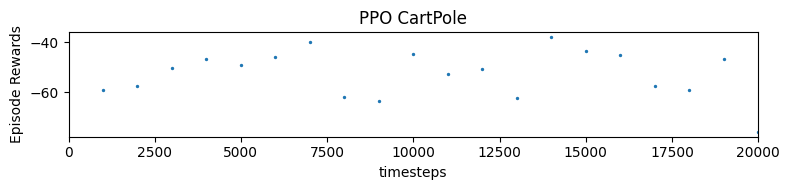

In [21]:
import matplotlib.pyplot as plt 
from stable_baselines3.common.results_plotter import plot_results
from stable_baselines3.common import results_plotter
plot_results([log_dir], 20_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()


### Eksperymenty z framestackingiem

In [ ]:
from gymnasium.wrappers import FrameStackObservation
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=1000)
# run_model(model_car)

In [51]:
def make_optimal_env():
    env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
    env = DummyVecEnv([lambda: env])
    env = VecFrameStack(env, n_stack=4)
    return env

In [55]:
def run_model_opt(model,time=1000):
    vec_env = make_optimal_env()
    obs = vec_env.reset()
    window_name = "Agent view"

    for i in range(time):
        action, _state = model.predict(obs,deterministic=True)
        obs,reward,done,info = vec_env.step(action)
        frame = vec_env.render()
        frame_bgr = cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
        cv2.imshow(window_name,frame_bgr)
        key = cv2.waitKey(1) & 0xFF
        if cv2.getWindowProperty(window_name,cv2.WND_PROP_VISIBLE) < 1:
            break
        if key == ord('q'):
            break
        if done:
            obs = vec_env.reset()
    cv2.destroyAllWindows()
    vec_env.close()

### Dyskretyzacja akcji

In [35]:
from stable_baselines3.common.vec_env import DummyVecEnv,VecFrameStack
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model_car = PPO("CnnPolicy",env_car,verbose=1,learning_rate=0.0001)
model_car.learn(total_timesteps=50000)
model_car.save("ppo_car_model_discrete")
run_model(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -56.4    |
| time/              |          |
|    fps             | 103      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -50.9       |
| time/                   |             |
|    fps                  | 91          |
|    iterations           | 2           |
|    time_elapsed         | 44          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013712382 |
|    clip_fraction        | 0.138       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explaine

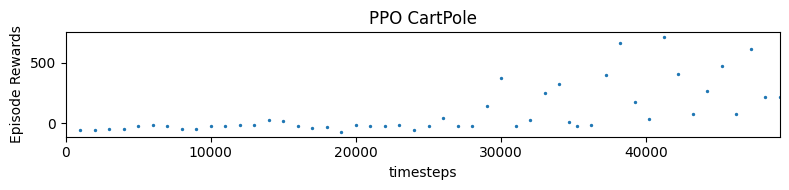

In [37]:
plot_results([log_dir], 50_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

### Sprawdzanie na współczynniku dyskontowym 0.9

In [65]:
from stable_baselines3.common.vec_env import DummyVecEnv,VecFrameStack
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model_car = PPO("CnnPolicy",env_car,verbose=1,learning_rate=0.0001,gamma=0.9)
model_car.learn(total_timesteps=50000)
model_car.save("ppo_car_model_g09")
run_model_opt(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -55.7    |
| time/              |          |
|    fps             | 108      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -44         |
| time/                   |             |
|    fps                  | 92          |
|    iterations           | 2           |
|    time_elapsed         | 44          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010032478 |
|    clip_fraction        | 0.108       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explaine

### Dużo gorsze wyniki

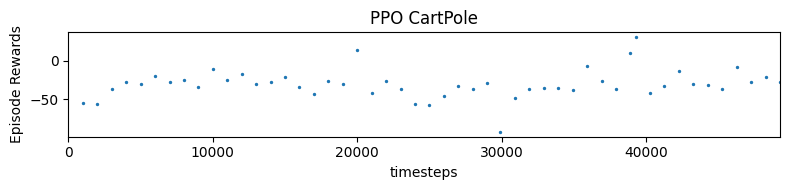

In [66]:
plot_results([log_dir], 50_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

In [57]:
run_model_opt(model_car)

In [63]:
from typing import Callable
def linear_with_min(initial_value: float, min_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_value)
    return func

In [68]:
from stable_baselines3.common.vec_env import DummyVecEnv,VecFrameStack
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
lr_schedule = linear_with_min(0.001,0.00001)
model_car = PPO("CnnPolicy",env_car,verbose=1,learning_rate=0.0005,gamma=0.999)
model_car.learn(total_timesteps=500000)
model_car.save("ppo_car_model_cont")
run_model(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -55.5    |
| time/              |          |
|    fps             | 112      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -55.7        |
| time/                   |              |
|    fps                  | 101          |
|    iterations           | 2            |
|    time_elapsed         | 40           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0056143547 |
|    clip_fraction        | 0.0485       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |

### Dla współczynnika dyskontowego = 0.999

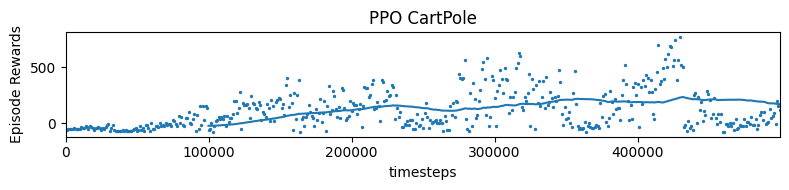

In [69]:
plot_results([log_dir], 500_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

### Dodanie eval callbacku żeby wybrać najlepszy model + zmniejszającego się współczynnika uczenia bo wcześniej rezultaty były trochę zaszumione

In [70]:
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
class BestRewardLogger(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self) -> bool:
        print(f"\n" + "="*30)
        print(f"NOWY REKORD: {self.parent.best_mean_reward:.2f} punktów!")
        print(f"Krok treningowy: {self.num_timesteps}")
        print("="*30 + "\n")
        return True

In [71]:
from stable_baselines3.common.callbacks import EvalCallback
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)

eval_env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
eval_env = Monitor(eval_env)
eval_env = DummyVecEnv([lambda: eval_env])
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./logs/best_model/",
    log_path="./logs/results/", 
    eval_freq=10000,
    deterministic=True, 
    render=False,
    verbose=1,
    callback_on_new_best=BestRewardLogger()
)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=500000,callback=eval_callback)
model_car.save("ppo_car_model_with_callback")
run_model_opt(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.


/home/tk2/projekty/InteligencjaObliczeniowa/.venv/lib/python3.12/site-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7517bcbc9160> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x75193d54f470>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -61.7    |
| time/              |          |
|    fps             | 106      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 1e+03      |
|    ep_rew_mean          | -55.3      |
| time/                   |            |
|    fps                  | 97         |
|    iterations           | 2          |
|    time_elapsed         | 42         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.00681888 |
|    clip_fraction        | 0.0474     |
|    clip_range           | 0.2        |
|    entropy_loss         | -4.25      |
|    explained_variance   | 0.00275    |
|    learning_rate        | 0.0003     |
|   

KeyboardInterrupt: 